## Comment utiliser ce notebook
Cliquer sur une cellule et presser Entrée pour éditer une cellule.<br/>
Appuyer sur Shift+Entrée pour exécuter la cellule.<br/>
Pour répondre à un exercice, remplacer la ligne
```python
# <- completer ici
```
par votre code et exécuter la cellule.
<hr/>

### Matplotlib

La librairie [Matplotlib](https://matplotlib.org/) est très utile pour produire des graphiques.

Sous-sections :
[Le modèle de graphique](#modele)&nbsp;|
[Interface objet vs fonctionnelle](#interfaces)&nbsp;|
[Sous-figures](#figures)&nbsp;|
[Utilisation de la couleur](#couleur)&nbsp;|
[Exercices](#exercices)&nbsp;

<a id="modele"></a>
### Le modèle de graphique

L'API de Matplotlib (i.e., l'ensemble des classes et méthodes fournies) est structurée autour de la notion d'[Artist](https://matplotlib.org/stable/api/artist_api.html#matplotlib.artist.Artist), qui désigne tout objet rendu sur un canvas.

Matplotlib distingue deux types d'`Artist` :
- les primitives (ligne, rectangle, image, texte, etc.) qu'on peut vouloir afficher ;
- les conteneurs (`Axes`, `Axis`, `Figure`) qui groupent ensemble certaines de ces primitives pour créer des graphiques.

Les principaux conteneurs que nous allons manipuler sont :
- `Figure`, qui désigne une figure, c'est-à-dire un ensemble d'une ou plusieurs sous-figures (objet de type `Axes`) à dessiner sur un canvas ;
- `Axes`, qui désigne une de ces sous-figures ;
- `Axis`, qui désigne un axe (x, y, z, ... ) d'une sous-figure.

<a id="interfaces"></a>
### Interface objet *vs* interface fonctionnelle

Pour manipuler ces conteneurs, l'API de Matplotlib fournit [deux interfaces](https://matplotlib.org/stable/users/explain/figure/api_interfaces.html) :
- l'interface __orientée objet__, qui permet de créer des objets des classes `Figure` et `Axes` et d'appeler leurs méthodes pour interagir avec eux ;

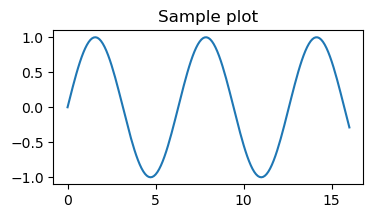

In [1]:
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=(4,2))
x = np.arange(0, 16.1, .1)
y = np.sin(x)
ax.plot(x, y)
ax.set_title("Sample plot")
plt.show()

- l'interface __fonctionnelle__, qui consiste à utiliser les fonctions du module `pyplot` directement : dans ce cas Matplotlib tente d'ajouter les primitives souhaitées aux dernières figures / sous-figures créées (ou les crée à la volée si besoin).

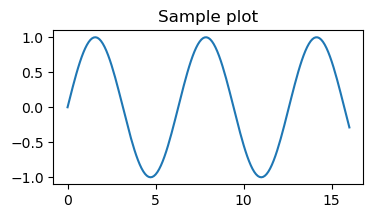

In [2]:
import matplotlib.pyplot as plt
import numpy as np
x = np.arange(0, 16.1, .1)
y = np.sin(x)
plt.figure(figsize=(4,2))
plt.plot(x, y)
plt.title("Sample plot")
plt.show()

<a id="figures"></a>
### Figures et sous-figures

__Figures__

<img src="../images/figure.webp" alt="figure" width="500"/>

Deux paramètres ont une influence sur la [taille de la figure](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/figure_size_units.html) :
- __figsize__ : les dimensions de la figure qui sont exprimées en inch (= 2.54 cm) par défaut (la taille par défaut est 6.4 x 4.8) et qui définissent la "taille du papier" sur lequel et dessinée la figure ;
- __dpi__ (*dot per inch*) : définit le nombre de pixels par inch qui agit si on l'augmente comme une "loupe rétrécissante" sur les primitives de la figure (dpi = 100 par défaut).

En effet on peut noter que :
- la largeur d'une ligne ou d'un caractère reste la même quelque soit la valeur de dpi.
 Par défaut Matplotlib utilise 72 *points per inch* (*ppi*) donc une ligne d'épaisseur 1 fera 1/72 d'inch, et un caractère de fonte 12 fera 12/72 inch de hauteur, etc.
- la taille du graphique affiché à l'écran n'est pas la "taille du papier" paramétrée par `figsize`, mais plutôt du __nombre de pixels__ de la figure, qui est sur chaque axe égal à`figsize` $\times$ `dpi`

Par exemple une figure de dimension $576 \times 144$ pixels peut être obtenue en prenant 
- figsize = $8$ inch $\times 2$ inch et dpi = $72$,  
- figsize = $4$ inch $\times 1$ inch et dpi = $144$,
- ...

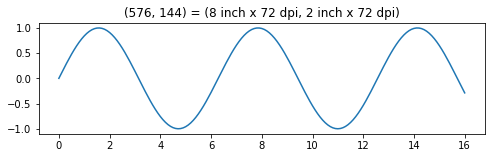

In [3]:
fig, ax = plt.subplots(figsize=(8,2), dpi=72)
ax.plot(x, y)
ax.set_title("(576, 144) = (8 inch x 72 dpi, 2 inch x 72 dpi)")
plt.show()

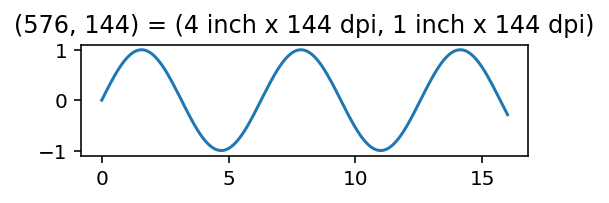

In [4]:
fig, ax = plt.subplots(figsize=(4,1), dpi=144)
ax.plot(x, y)
ax.set_title("(576, 144) = (4 inch x 144 dpi, 1 inch x 144 dpi)")
plt.show()

__Sous-figures__

La méthode `subplots` permet de mettre plusieurs [sous-figures](https://matplotlib.org/stable/users/explain/axes/index.html) sur une même figure, en les plaçant sur une grille :

<img src="../images/subplots.png" alt="figure" width="500"/>


Par exemple, cette figure est composée de 4 sous-figures réparties sur 2 lignes et 2 colonnes : 

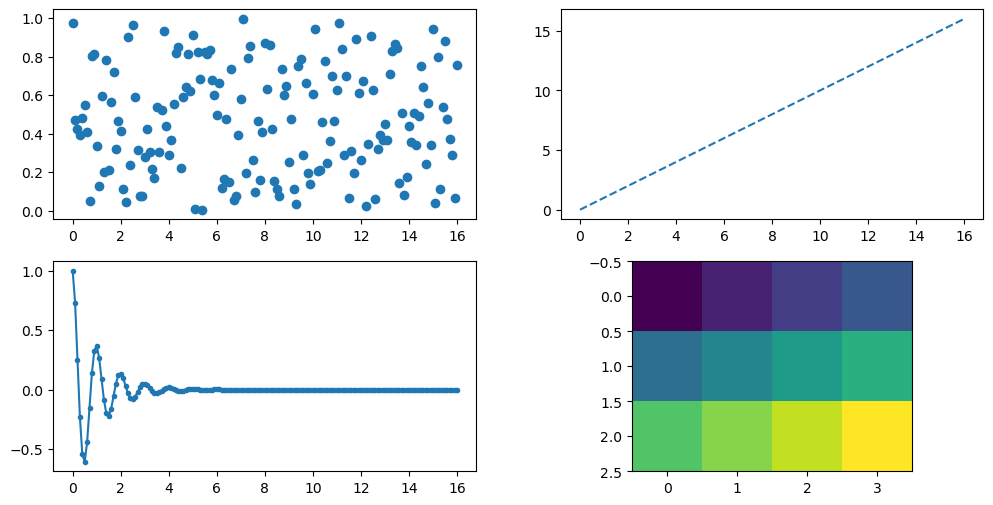

In [5]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(12,6))
axs[0,0].scatter(x,np.random.rand(len(x)))
axs[0,1].plot(x,x,linestyle='--')
axs[1,0].plot(x,np.exp(-x) * np.cos(2*np.pi*x), color='tab:blue', marker='o', markersize=3)
axs[1,1].imshow(np.arange(12).reshape((3,4)))
plt.show()

Une autre stratégie (héritée de Matlab) consiste à créer une figure vide puis à utiliser la fonction `add_subplot` pour ajouter une à une chacune des sous-figures.

Dans ce cas,
l'appel à la fonction 

 `add_subplot(r, c, i)` 
 ou `add_subplot(rci)`

prend trois arguments :
- `r (row)` donne le nombre de lignes de la grille 
- `c (col)` donne le nombre de colonnes de la grille
- `i (index)` donne l'index de la sous-figure dans cette grille

![sens parcours](../images/sens_parcours.png)

Par exemple, `add_subplot(233)` crée une sous-figure à l'index `i=3` (donc en haut à droite) dans une grille de sous-figures comportant `r=2` lignes et `c=3` colonnes.

Dans l'exemple suivant, on utilise `add_subplot` pour ajouter successivement 4 sous-figures sur une grille :

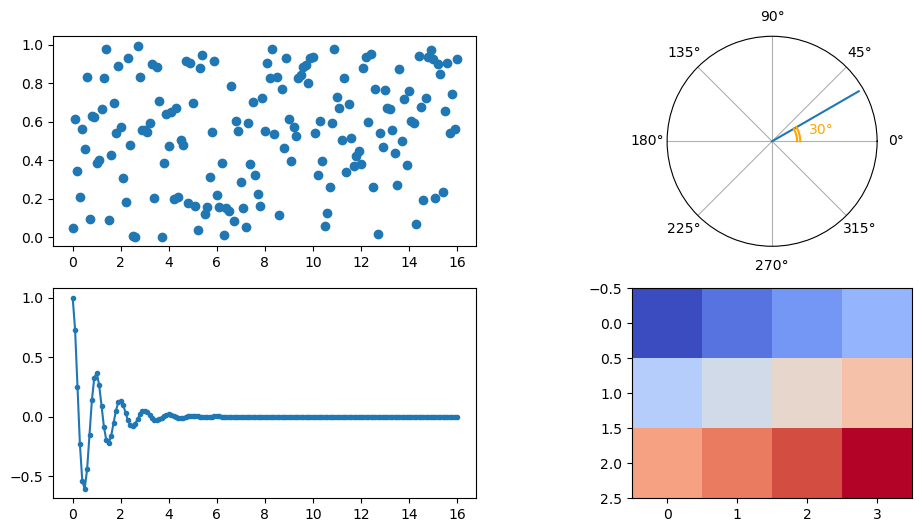

In [6]:
fig = plt.figure(figsize=(12,6))
fig.add_subplot(221).scatter(x,np.random.rand(len(x)))
ax= fig.add_subplot(222,projection="polar")
ax.set_rticks([])
ax.plot([np.pi/6]*len(x),x,linestyle='-')
[ax.plot(np.linspace(0., np.pi/6, len(x)),[r]*len(x),linestyle='-', color='orange') for r in (4., 4.5)]
ax.annotate('30°',xy=(np.pi/15,6),color='orange')
fig.add_subplot(223).plot(x,np.exp(-x) * np.cos(2*np.pi*x), color='tab:blue', marker='o', markersize=3)
fig.add_subplot(224).imshow(np.arange(12).reshape((3,4)),cmap='coolwarm')
plt.show()

On peut aussi utiliser la méthode `add_axes` pour ajouter une sous-figure. 
La méthode prend comme argument un rectangle `[left, bottom, width, height]` donnant les coordonnées et la taille de la sous-figure par rapport à la figure principale :

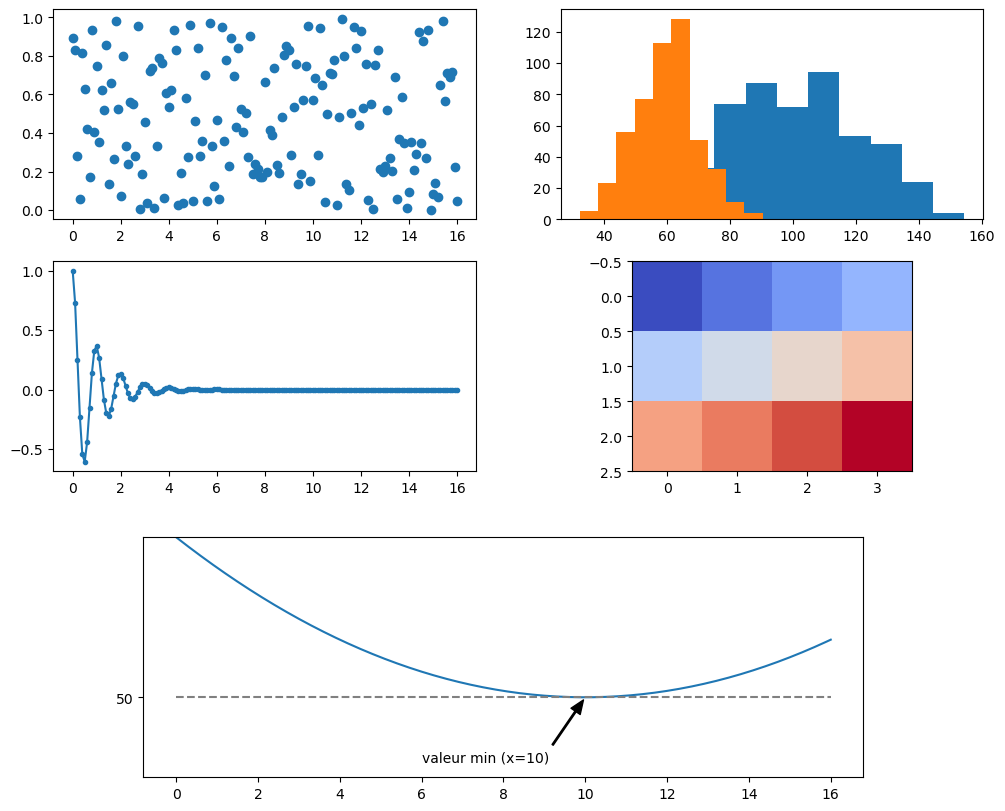

In [7]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(12,6))
axs[0,0].scatter(x,np.random.rand(len(x)))
axs[0,1].hist(np.random.normal(100, 20, size=500),histtype='barstacked')
axs[0,1].hist(np.random.normal(60, 10, size=500),histtype='barstacked')
axs[1,0].plot(x,np.exp(-x) * np.cos(2*np.pi*x), color='tab:blue', marker='o', markersize=3)
axs[1,1].imshow(np.arange(12).reshape((3,4)),cmap='coolwarm')

# on ajoute une nouvelle sous-figure
new_ax = fig.add_axes([0.2,-0.4,.6,0.4])
new_ax.plot(x,50+ (10-x)*(10-x))
new_ax.plot(x,len(x)*[50], color="grey", linestyle='--')
new_ax.set_ylim([0.,150])
new_ax.annotate('valeur min (x=10)', xy=(10, 50), xytext=(6, 10),
            arrowprops=dict(facecolor='black', width=1, headwidth=8, headlength=10, shrink=0.05))
new_ax.set_yticks([50])
plt.show()

Si l'on veut un agencement plus compliqué qu'un simple grille, on peut utiliser la méthode `subplot_mosaic` pour [arranger en mosaique](https://matplotlib.org/stable/users/explain/axes/mosaic.html#mosaic) les sous-figures : 

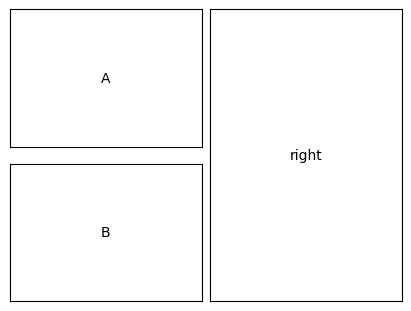

In [8]:
fig, axs = plt.subplot_mosaic([['A', 'right'], ['B', 'right']],
                              figsize=(4, 3), layout='constrained')
for ax_name, ax in axs.items():
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.5, 0.5, ax_name, ha='center', va='center')


<a id="couleur"></a>
### Utilisation de la couleur

Maplotlib propose un grand choix de [couleurs](https://matplotlib.org/stable/users/explain/colors/index.html).

__couleurs individuelles__

Une couleur est encodée par $4$ nombres réels de l'intervalle [0,1]: 
- un nombre pour le canal rouge (R)
- un nombre pour le canal vert (G)
- un nombre pour le canal bleu (B)
- un nombre pour la transparence (A)

Par exemple, une couleur rouge avec 50% de transparence peut être obtenue avec 
R=0.8, G=0.2, B=0.1 et A=0.5.

Une couleur individuelle peut être spécifiée de plusieurs façons :
- par le nom d'une couleur prédéfinie, comme `'red'`
- par un code hexadécimal, comme `'#FF5733'`
- par trois nombres réels `(R,G,B)` 
- par quatre nombres réels `(R,G,B,A)`

L'exemple suivant montre 4 exemples de définition de couleur pour afficher deux classes A et B.

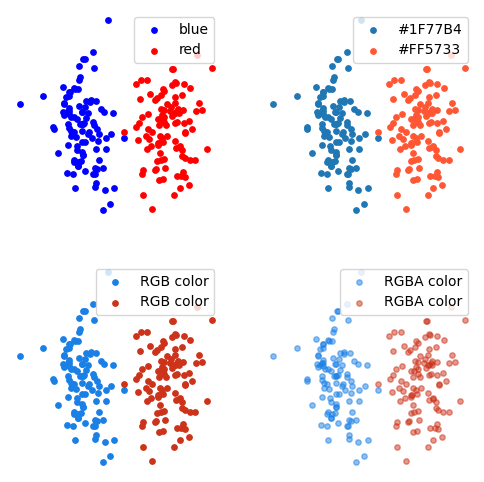

In [9]:
rng = np.random.default_rng()
X_A = rng.normal((-3.,0.),1.2,(100,2))
X_B = rng.normal((3.,0.),1.2,(100,2))

fig = plt.figure(figsize=(6,6))
color_options = [('blue','red'),('#1F77B4','#FF5733'),((0.1, 0.5, 0.9),(0.8, 0.2, 0.1)),((0.1, 0.5, 0.9, 0.5),(0.8, 0.2, 0.1,0.5))]
label_options = [('blue','red'),('#1F77B4','#FF5733'),('RGB color','RGB color'),('RGBA color','RGBA color')]
for i,((color_A,color_B),(label_A,label_B)) in enumerate(zip(color_options,label_options)):
    ax = fig.add_subplot(2,2,i+1)
    ax.scatter(X_A[:,0],X_A[:,1], color=color_A, label=label_A, s=15)
    ax.scatter(X_B[:,0],X_B[:,1], color=color_B, label=label_B, s=15)
    ax.set_axis_off()
    ax.legend(loc='upper right')
plt.show()

__Cartes de couleurs (colormaps)__

Il existe de nombreuses listes prédéfinies de couleurs ([*colormaps*](https://matplotlib.org/stable/users/explain/colors/colormaps.html#colormaps)).

In [10]:
import matplotlib as mpl
list(mpl.colormaps)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',
 'inferno_r',
 'plasma_r',
 'viri

Par exemple, la liste Set3 définit une liste de couleurs (triplets R,G,B) :

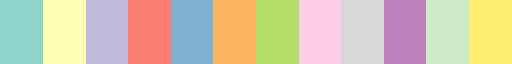

In [11]:

m = mpl.colormaps['Set3']
m

In [12]:
m.colors

((0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
 (1.0, 1.0, 0.7019607843137254),
 (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
 (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
 (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
 (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
 (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
 (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
 (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
 (0.7372549019607844, 0.5019607843137255, 0.7411764705882353),
 (0.8, 0.9215686274509803, 0.7725490196078432),
 (1.0, 0.9294117647058824, 0.43529411764705883))

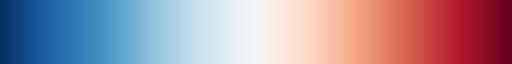

In [13]:
mpl.colormaps['RdBu_r']

Chaque colormap peut être utilisée comme une échelle de couleurs :
c'est une fonction qui associe à tout nombre réel de [0,1] une couleur (R,G,B,A)  :

In [14]:
m(.8)

(0.7372549019607844, 0.5019607843137255, 0.7411764705882353, 1.0)

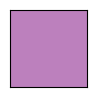

In [15]:
plt.figure(figsize=(1,1),frameon=False).add_subplot(xticks=[],yticks=[]).imshow([[m(.8)]])

On peut ainsi spécifier la couleur de chaque point dans
un scatterplot, en combinant les options `c` et `cmap` :

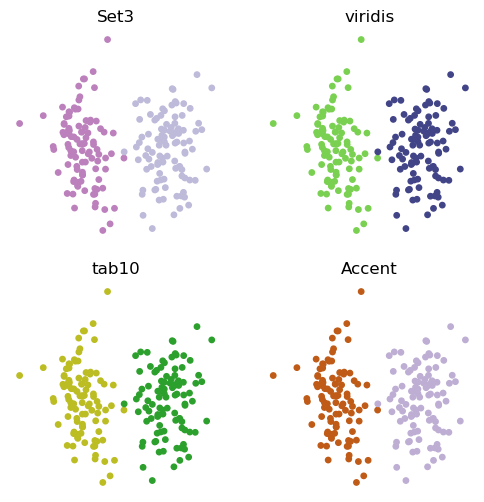

In [16]:
fig = plt.figure(figsize=(6,6))
color_maps = ['Set3','viridis','tab10','Accent']
ones = np.ones(len(X_A))
for i,name in enumerate(color_maps):
    ax = fig.add_subplot(2,2,i+1)
    ax.scatter(X_A[:,0],X_A[:,1], c=ones*.8, cmap=name, s=15, vmin=0., vmax=1.)
    ax.scatter(X_B[:,0],X_B[:,1], c=ones*.2, cmap=name, s=15, vmin=0., vmax=1.)
    ax.set_title(name)
    ax.set_axis_off()
plt.show()

<a id="exercices"></a>
### Exercices

On veut visualiser la distribution de chaque attribut dans le jeu de données Breast Cancer Wisonsin.

On charge les données depuis un fichier csv :

In [17]:
import pandas as pd
features = ['id', 'clump', 'uniformity_cell_size', 'uniformity_cell_shape', 'marginal_adhesion','single_epithelial_cell_size', 'bare_nuclei', 'chromatin', 'normal_nucleoli', 'mitoses']
cls_att = 'class'

# <- completer ici
df = pd.read_csv('../data/breast-cancer-wisconsin.data.with_null',names=features+[cls_att])
df = df.set_index('id')
df = df.dropna()
df

,clump,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,chromatin,normal_nucleoli,mitoses,class
id,,,,,,,,,,
1000025,5,1,1,1,2,1.0,3,1,1,2
1002945,5,4,4,5,7,10.0,3,2,1,2
1015425,3,1,1,1,2,2.0,3,1,1,2
1016277,6,8,8,1,3,4.0,3,7,1,2
1017023,4,1,1,3,2,1.0,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...
776715,3,1,1,1,3,2.0,1,1,1,2
841769,2,1,1,1,2,1.0,1,1,1,2
888820,5,10,10,3,7,3.0,8,10,2,4


__Exercice__. 
Ecrire un programme qui affiche pour chaque attribut un histogramme décrivant les valeurs qu'il prend pour chaque classe. 
On doit obtenir un résultat comme celui-ci :

<img src='../images/hist.png' width='600' alt='histo'/>

In [ ]:
fig, axs = plt.subplots(ncols=2, nrows=5, figsize=(8,16))
# <- completer ici


__Exercice__.
Modifier le code précédent pour obtenir une image de taille 2592 x 4608 pixels avec 144 pixels/inch (*i.e.*, 144 dpi).

__Exercice__. 
Modifier le code précédent pour utiliser les couleurs de la colormap `RdBu_r`.
On doit obtenir le résultat suivant :

<img src='../images/hist_bleu_rouge.png' width='600' alt='histo'/>